In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE,
    LINE_STYLE,
    GRID_STYLE,
    slate_teal,
    deep_red,
    warm_orange,
    navy,
    bordeaux,
    mid_grey,
)
from analysis import from_round_one, index_at_or_before

FIG_DIR = "../figures/evaluation/scalability"
os.makedirs(FIG_DIR, exist_ok=True)

PHASE_LABELS = {0: "Idle", 1: "Training", "eval": "Evaluation", 3: "Collect"}
PHASE_COLORS = {0: mid_grey, 1: slate_teal, "eval": warm_orange, 3: deep_red}


def slice_to_round(df, round_index):
    rounds = df[df.field == "current_round"].copy()
    rounds["v"] = pd.to_numeric(rounds.value, errors="coerce")

    starts = rounds[rounds.v == round_index].groupby("node").timestamp.min()
    ends = rounds[rounds.v == round_index + 1].groupby("node").timestamp.min()

    lo = df["node"].map(starts)
    hi = df["node"].map(ends)

    keep = lo.notna() & (df["timestamp"] >= lo) & (hi.isna() | (df["timestamp"] < hi))
    return df[keep]


def per_phase_cpu(df_node):
    cpu = df_node[df_node.field == "cpu_total_ns"].copy()
    cpu["v"] = pd.to_numeric(cpu.value, errors="coerce") * 10.0
    cpu = cpu.dropna(subset=["v"]).sort_values("timestamp")

    stage = df_node[df_node.field == "stage"].copy()
    stage["v"] = pd.to_numeric(stage.value, errors="coerce")
    stage = stage.dropna(subset=["v"]).sort_values("timestamp")

    cpu_ts = cpu.timestamp.values
    cpu_seconds = cpu.v.values
    stage_ts = stage.timestamp.values
    stage_phase = stage.v.astype(int).values

    cpu_by_phase = {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0}

    for i in range(len(cpu_ts) - 1):

        cpu_delta = cpu_seconds[i + 1] - cpu_seconds[i]
        if cpu_delta < 0:
            continue

        j = index_at_or_before(stage_ts, cpu_ts[i])
        phase = int(stage_phase[j]) if j >= 0 else 0
        cpu_by_phase[phase] += cpu_delta

    return cpu_by_phase

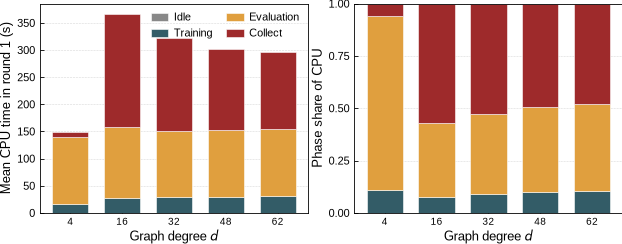

In [2]:
SQZ_PHASE_DIR = "../metrics/b2_squeezenet_degree_sweep_n64"
SQZ_PHASE_ROUND = 1

sqz_agg = {}

for name, path in list_runs(SQZ_PHASE_DIR):
    config = read_config_from_csv(path)

    if config.get("topology_type") != "circulant":
        continue

    degree = int(config["graph_degree"])
    if degree not in sqz_agg:
        sqz_agg[degree] = {0: [], 1: [], "eval": [], 3: []}

    df = slice_to_round(from_round_one(load_file(path)), SQZ_PHASE_ROUND)

    for node, df_node in df.groupby("node"):

        cpu_by_phase = per_phase_cpu(df_node)
        sqz_agg[degree][0].append(cpu_by_phase[0])
        sqz_agg[degree][1].append(cpu_by_phase[1])
        sqz_agg[degree]["eval"].append(cpu_by_phase[2] + cpu_by_phase[4])
        sqz_agg[degree][3].append(cpu_by_phase[3])

SQZ_DEGREES = sorted(sqz_agg)

sqz_means = {
    degree: {phase: float(np.mean(samples)) for phase, samples in row.items()}
    for degree, row in sqz_agg.items()
}
sqz_totals = {degree: sum(sqz_means[degree].values()) for degree in SQZ_DEGREES}
sqz_shares = {
    degree: {phase: sqz_means[degree][phase] / sqz_totals[degree] for phase in [0, 1, "eval", 3]}
    for degree in SQZ_DEGREES
}

x_positions = np.arange(len(SQZ_DEGREES))

fig_combo, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

bottom_abs = np.zeros(len(SQZ_DEGREES))
bottom_rel = np.zeros(len(SQZ_DEGREES))

for phase in [0, 1, "eval", 3]:
    abs_heights = np.array([sqz_means[degree][phase] for degree in SQZ_DEGREES])
    share_heights = np.array([sqz_shares[degree][phase] for degree in SQZ_DEGREES])

    axes[0].bar(
        x_positions,
        abs_heights,
        bottom=bottom_abs,
        color=PHASE_COLORS[phase],
        label=PHASE_LABELS[phase],
        width=0.7,
        edgecolor="white",
        linewidth=0.4,
    )
    axes[1].bar(x_positions, share_heights, bottom=bottom_rel, color=PHASE_COLORS[phase], width=0.7, edgecolor="white", linewidth=0.4)

    bottom_abs += abs_heights
    bottom_rel += share_heights

for ax in axes:
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(degree) for degree in SQZ_DEGREES], fontsize=7)
    ax.set_xlabel(r"Graph degree $d$")
    ax.grid(axis="y", **GRID_STYLE)

axes[0].set_ylabel("Mean CPU time in round 1 (s)")
axes[1].set_ylabel("Phase share of CPU")
axes[1].set_ylim(0, 1.0)
axes[1].set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
axes[0].legend(loc="upper right", frameon=False, ncol=2)

plt.tight_layout()
save_figure(fig_combo, f"{FIG_DIR}/cpu_per_phase_stacked_by_degree_squeezenet.pdf")
plt.show()

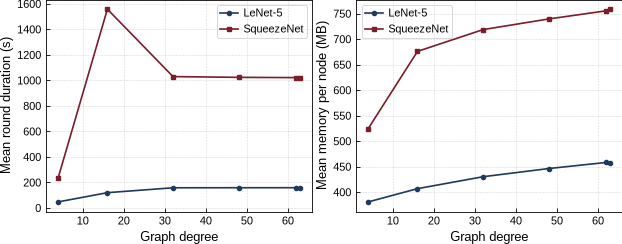

In [3]:
LENET_DIR = "../metrics/b1_degree_sweep"
SQZ_DIR = "../metrics/b2_squeezenet_degree_sweep_n64"


def agg_runs(directory):
    rows = []

    for name, path in list_runs(directory):
        config = read_config_from_csv(path)
        degree = int(config["graph_degree"])

        df = load_file(path)
        memory_mb = pd.to_numeric(df[df.field == "memory_mb"]["value"], errors="coerce").dropna()

        round_marks = df[df.field == "current_round"][["timestamp", "node", "value"]].copy()
        round_marks["v"] = pd.to_numeric(round_marks.value, errors="coerce")
        round_marks = round_marks.dropna(subset=["v"]).sort_values("timestamp")

        round_secs = []
        for _, node_rows in round_marks.groupby("node"):
            round_starts = node_rows.groupby("v")["timestamp"].min().sort_index()
            gaps = round_starts.diff().dropna().dt.total_seconds()
            round_secs.append(float(gaps.mean()))

        rows.append((degree, float(np.mean(round_secs)), float(memory_mb.mean())))

    return pd.DataFrame(rows, columns=["degree", "round_s", "mem_mb"]).groupby("degree").mean().reset_index()


lenet = agg_runs(LENET_DIR)
sqz = agg_runs(SQZ_DIR)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGURE_SIZE)

ax1.plot(lenet.degree, lenet.round_s, color=navy, marker="o", markersize=3, label="LeNet-5", **LINE_STYLE)
ax1.plot(sqz.degree, sqz.round_s, color=bordeaux, marker="s", markersize=3, label="SqueezeNet", **LINE_STYLE)
ax1.set_xlabel("Graph degree")
ax1.set_ylabel("Mean round duration (s)")
ax1.grid(**GRID_STYLE)
ax1.legend(loc="best", framealpha=0.9)

ax2.plot(lenet.degree, lenet.mem_mb, color=navy, marker="o", markersize=3, label="LeNet-5", **LINE_STYLE)

ax2.plot(sqz.degree, sqz.mem_mb, color=bordeaux, marker="s", markersize=3, label="SqueezeNet", **LINE_STYLE)

ax2.set_xlabel("Graph degree")
ax2.set_ylabel("Mean memory per node (MB)")
ax2.grid(**GRID_STYLE)
ax2.legend(loc="best", framealpha=0.9)

fig.tight_layout()

save_figure(fig, f"{FIG_DIR}/squeezenet_vs_lenet_overlay.pdf")
plt.show()